Loading the initial reference set (base molecules)...
   -> Calculating fingerprints for 3092 reference SMILES...

Processing Iter 0...
Calculating fingerprints for all 3819 molecules and comparing them with the initial reference set...


Iter 0: 100%|████████████████████████████████████████████████████████████████████| 3819/3819 [00:01<00:00, 2216.45it/s]



Processing Iter 1...
Calculating fingerprints for all 3755 molecules and comparing them with the initial reference set...


Iter 1: 100%|████████████████████████████████████████████████████████████████████| 3755/3755 [00:01<00:00, 2364.12it/s]



Processing Iter 2...
Calculating fingerprints for all 3874 molecules and comparing them with the initial reference set...


...


Processing Iter 3...
Calculating fingerprints for all 3988 molecules and comparing them with the initial reference set...


Iter 3: 100%|████████████████████████████████████████████████████████████████████| 3988/3988 [00:01<00:00, 2503.01it/s]



Processing Iter 4...
Calculating fingerprints for all 4353 molecules and comparing them with the initial reference set...


Iter 4: 100%|████████████████████████████████████████████████████████████████████| 4353/4353 [00:01<00:00, 2561.15it/s]



Drawing a 10x8 plot without mean/peak markers...
Plot saved successfully.


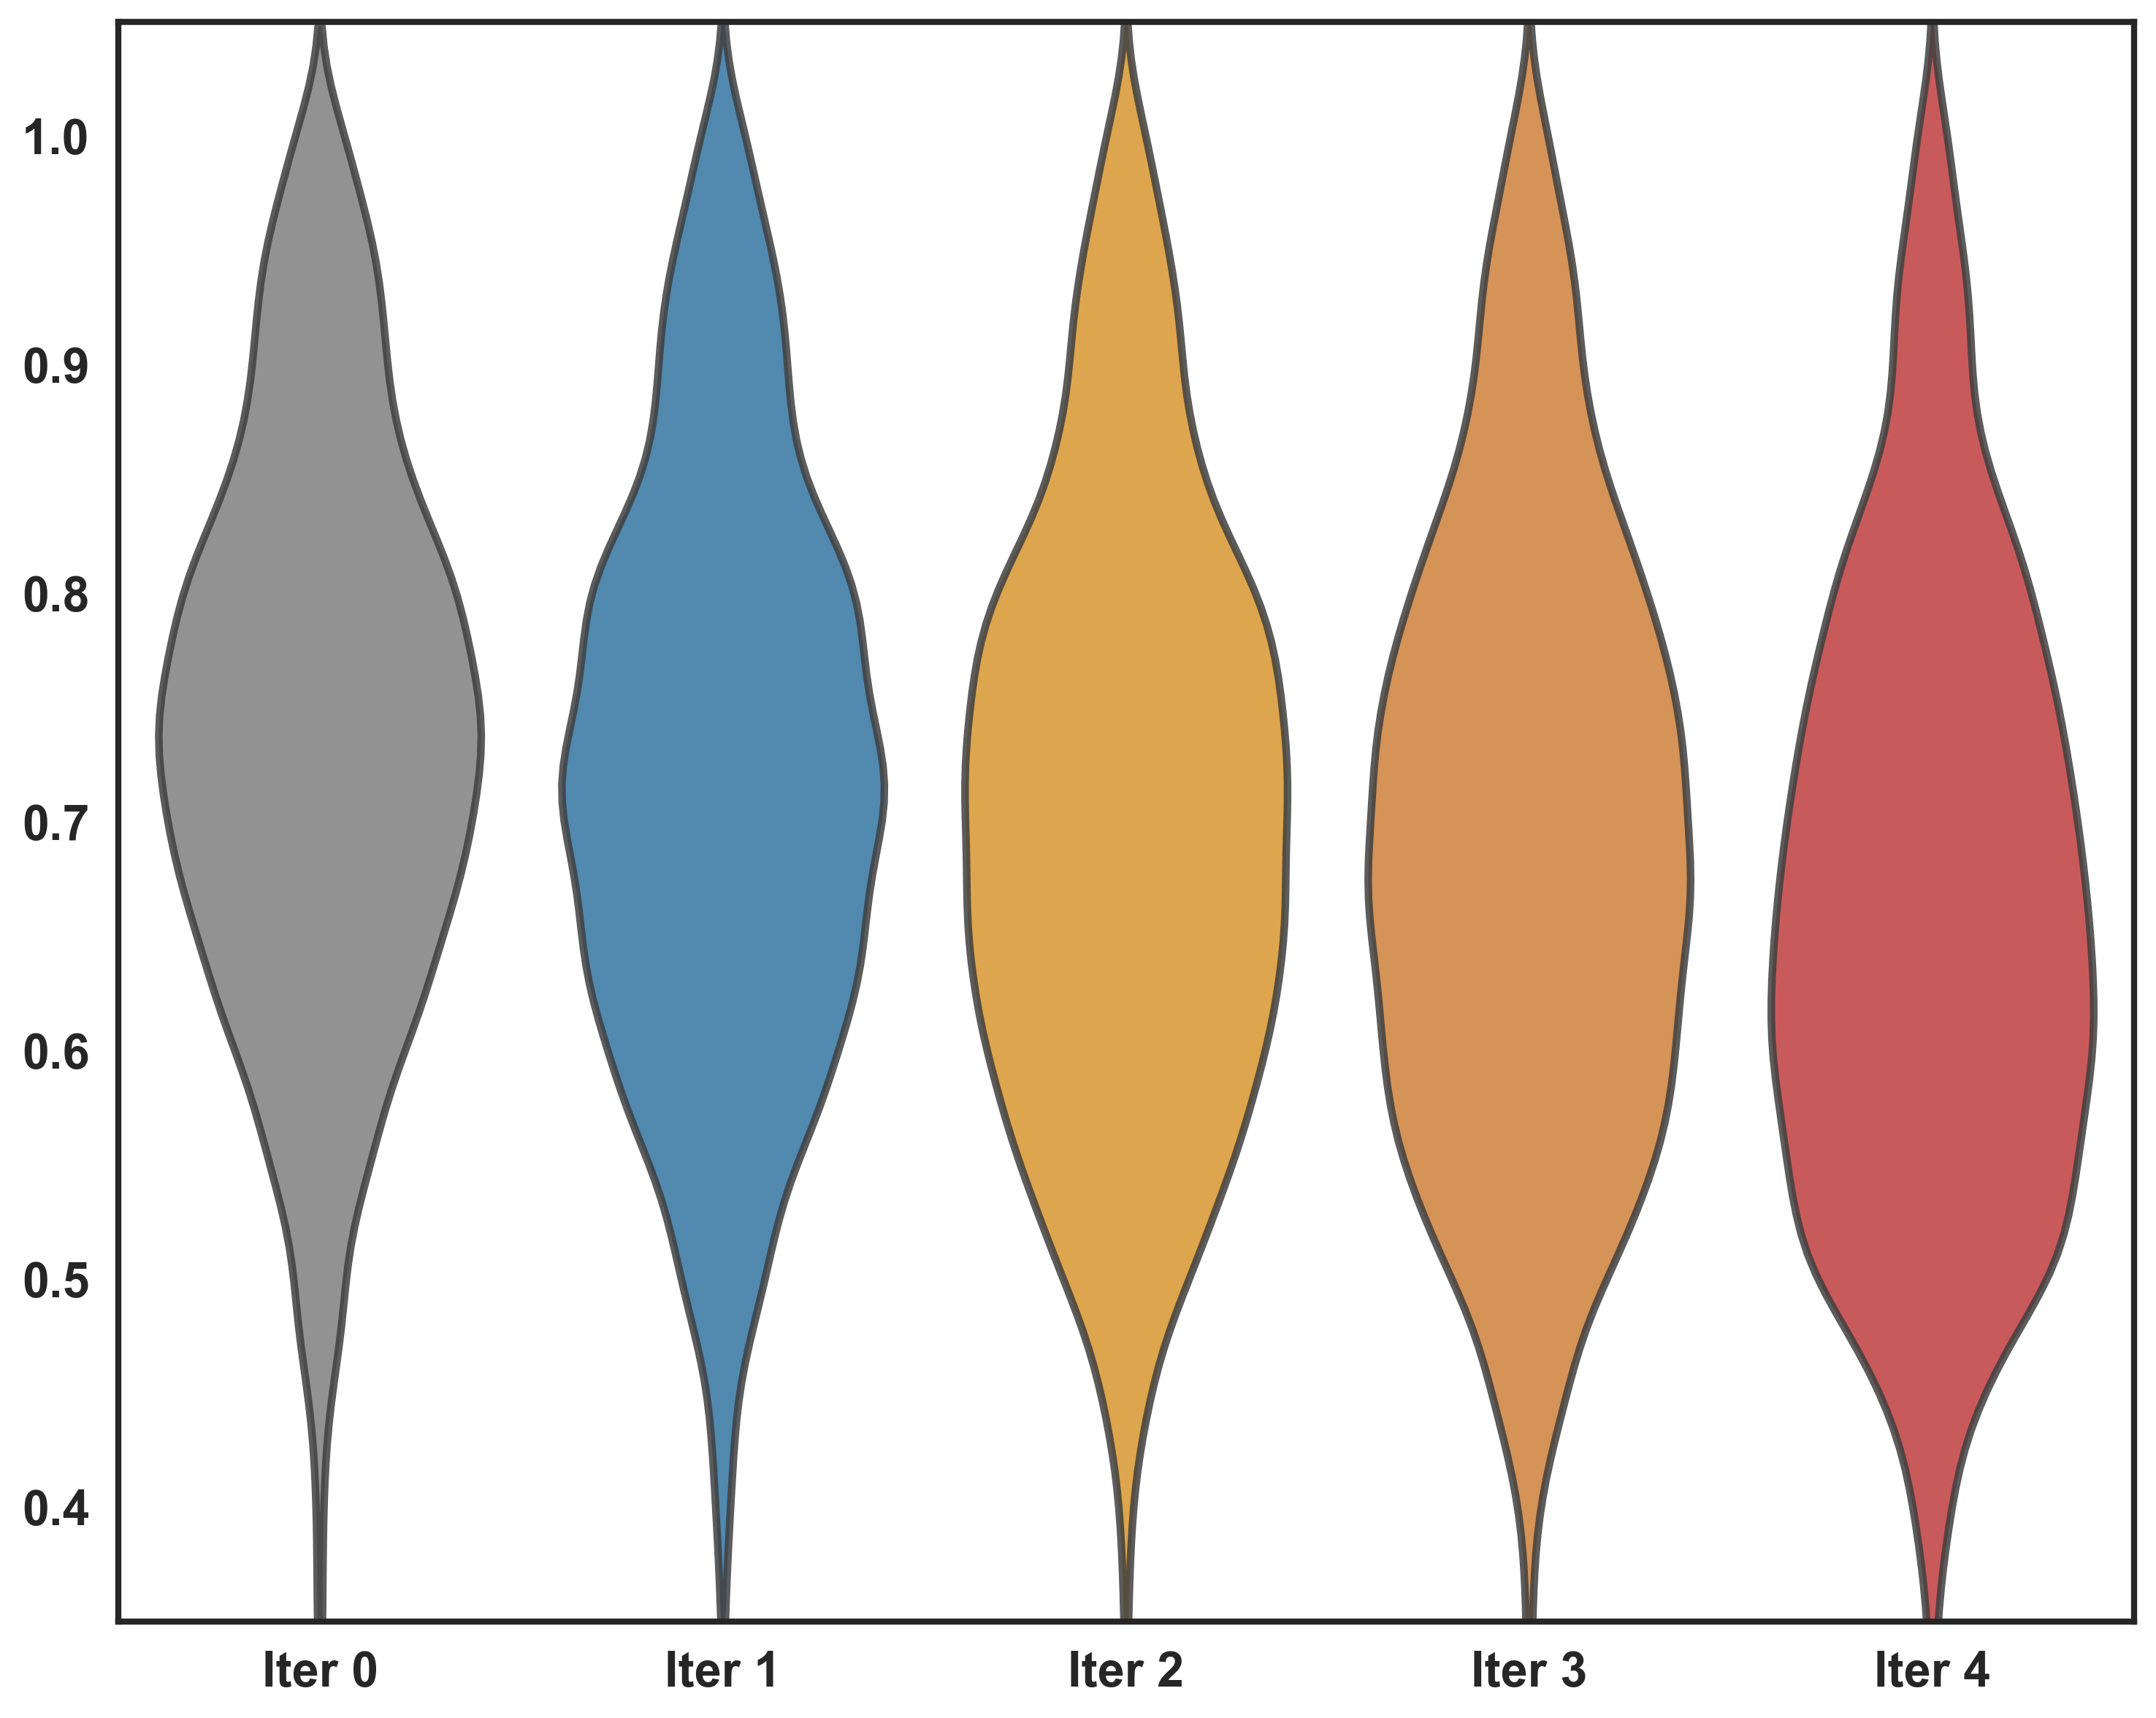


Similarity shifts across active-learning iterations (full-set means and KDE peaks)
Initial baseline | Iter 0: Mean 0.7371 | Peak 0.7371
----------------------------------------------------------------------
Iter 1: Mean 0.7188 | Peak 0.7138
   Mean decrease: 0.0183 | KDE peak decrease: 0.0234
----------------------------------------------------------------------
Iter 2: Mean 0.7011 | Peak 0.7130
   Mean decrease: 0.0360 | KDE peak decrease: 0.0241
----------------------------------------------------------------------
Iter 3: Mean 0.6889 | Peak 0.6745
   Mean decrease: 0.0482 | KDE peak decrease: 0.0626
----------------------------------------------------------------------
Iter 4: Mean 0.6619 | Peak 0.6172
   Mean decrease: 0.0752 | KDE peak decrease: 0.1200
----------------------------------------------------------------------


In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit import RDLogger
from tqdm import tqdm
from scipy.stats import gaussian_kde

# Disable RDKit logging
RDLogger.DisableLog('rdApp.*')

# ==========================================
# 1. File paths (relative to this script)
# ==========================================
# Place this script in Firefly-Geni/analysis/Tanimoto-similarity/.
# In notebooks, run from Firefly-Geni/analysis/Tanimoto-similarity/.
SCRIPT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parent.parent

# Use the original training set as the fixed reference for all iterations.
base_train_path = (
    PROJECT_ROOT / "dataset_tadf" / "dataset_gen" /
    "gendata_est_sa" / "token_dataset" / "train.csv"
)

# Generated molecule files: initial model and four iterations.
path_iter0 = SCRIPT_DIR / "filtered_novel_smiles_epoch049_iter-0.csv"
path_iter1 = SCRIPT_DIR / "filtered_novel_smiles_epoch049_iter-1.csv"
path_iter2 = SCRIPT_DIR / "filtered_novel_smiles_epoch049_iter-2.csv"
path_iter3 = SCRIPT_DIR / "filtered_novel_smiles_epoch049_iter-3.csv"
path_iter4 = SCRIPT_DIR / "filtered_novel_smiles_epoch049_iter-4.csv"

# ==========================================
# 2. Molecular fingerprint extraction
# ==========================================
def get_fingerprints(smiles_list):
    """Convert SMILES to Morgan fingerprints"""
    fps = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
                fps.append(fp)
        except:
            pass
    return fps

# ==========================================
# 3. Build the fixed initial reference set
# ==========================================
print("Loading the initial reference set (base molecules)...")
df_base = pd.read_csv(base_train_path)
base_smiles = df_base['TADF_SMILES'].dropna().unique().tolist()

print(f"   -> Calculating fingerprints for {len(base_smiles)} reference SMILES...")
base_fps = get_fingerprints(base_smiles)

# ==========================================
# 4. Calculate similarities for all generated molecules
# ==========================================
def calculate_max_similarity(gen_csv_path, epoch_name):
    print(f"\nProcessing {epoch_name}...")
    df_gen = pd.read_csv(gen_csv_path)

    # Get all non-null SMILES
    gen_smiles = df_gen['SMILES'].dropna().tolist()

    print(f"Calculating fingerprints for all {len(gen_smiles)} molecules and comparing them with the initial reference set...")
    gen_fps = get_fingerprints(gen_smiles)

    max_sims = []
    for fp in tqdm(gen_fps, desc=f"{epoch_name}"):
        sims = DataStructs.BulkTanimotoSimilarity(fp, base_fps)
        max_sims.append(max(sims))

    return pd.DataFrame({
        'Max_Tanimoto_Similarity': max_sims,
        'Epoch': epoch_name
    })

# Process all molecules in each iteration
df_iter0 = calculate_max_similarity(path_iter0, 'Iter 0')
df_iter1 = calculate_max_similarity(path_iter1, 'Iter 1')
df_iter2 = calculate_max_similarity(path_iter2, 'Iter 2')
df_iter3 = calculate_max_similarity(path_iter3, 'Iter 3')
df_iter4 = calculate_max_similarity(path_iter4, 'Iter 4')

# Combine the results
df_all = pd.concat(
    [df_iter0, df_iter1, df_iter2, df_iter3, df_iter4],
    ignore_index=True
)

# ==========================================
# 5. Draw the vertical violin plot
#    Keep ticks, colors, and all four borders; the reference-line code below is disabled
#    Do not display mean/peak annotations or markers
# ==========================================
print("\nDrawing a 10x8 plot without mean/peak markers...")

# color_dict = {
#     'Iter 0': '#7f7f7f',  # gray
#     'Iter 1': '#1f77b4',  # blue
#     'Iter 2': '#ff7f0e',  # orange
#     'Iter 3': '#2ca02c',  # green
#     'Iter 4': '#d62728'   # red
# }
color_dict = {'Iter 0': '#7f7f7f', 'Iter 1': '#1f77b4', 'Iter 2':'#f39c12', 'Iter 3':'#e67e22', 'Iter 4':'#d62728'}
# Calculate means and KDE peaks for all iterations:
# 1. The Iter 0 peak is available for the optional reference line
# 2. Means and peaks are reported in the terminal
peak_dict = {}
mean_dict = {}

for epoch_name in color_dict.keys():
    epoch_data = df_all[df_all['Epoch'] == epoch_name]['Max_Tanimoto_Similarity']
    mean_dict[epoch_name] = epoch_data.mean()

    kde = gaussian_kde(epoch_data)
    x_range = np.linspace(epoch_data.min(), epoch_data.max(), 1000)
    y_range = kde(x_range)
    peak_dict[epoch_name] = x_range[np.argmax(y_range)]

# Use a 10x8 figure
plt.figure(figsize=(10, 8), dpi=300)
sns.set_theme(style="white", rc={"axes.linewidth": 2.0})

# Draw the vertical violin plot
ax = sns.violinplot(
    data=df_all,
    x='Epoch',
    y='Max_Tanimoto_Similarity',
    hue='Epoch',
    palette=color_dict,
    dodge=False,
    orient='v',
    inner=None,
    linewidth=2.5,
    alpha=0.85
)

# Optional horizontal reference line across all iterations
# Use the Iter 0 peak as the reference without a peak marker
# base_peak = peak_dict['Iter 0']
# ax.axhline(
#     y=base_peak,
#     color='gray',
#     linestyle='--',
#     linewidth=2.5,
#     zorder=0
# )

# Do not draw Mean or Peak markers
# The following elements are omitted:
# 1. White diamond markers for peaks
# 2. White circle markers for means
# 3. All mean/peak annotations within the plot

# Hide the redundant legend while supporting older seaborn versions.
legend = ax.get_legend()
if legend is not None:
    legend.remove()

# Clear axis labels to prevent seaborn from displaying column names
ax.set_xlabel('')
ax.set_ylabel('')

# Keep tick labels on both axes and use a large font
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

# Show and thicken all four borders
for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(2.0)

# Keep the original y-axis range
plt.ylim(0.35, 1.05)

# Prevent tick labels from being clipped when saving
plt.tight_layout()

output_img = SCRIPT_DIR / "violin_plot_evolution_vertical_no_mean_peak_icons.png"
plt.savefig(output_img, transparent=False, dpi=300)

print("Plot saved successfully.")
plt.show()

# ==========================================
# 6. Calculate and report mean and peak shifts
# ==========================================
print("\n" + "=" * 70)
print("Similarity shifts across active-learning iterations (full-set means and KDE peaks)")
print("=" * 70)

print(f"Initial baseline | Iter 0: Mean {mean_dict['Iter 0']:.4f} | Peak {peak_dict['Iter 0']:.4f}")
print("-" * 70)

for it in ['Iter 1', 'Iter 2', 'Iter 3', 'Iter 4']:
    mean_val = mean_dict[it]
    peak_val = peak_dict[it]

    mean_shift = mean_dict['Iter 0'] - mean_val
    peak_shift = peak_dict['Iter 0'] - peak_val

    print(f"{it}: Mean {mean_val:.4f} | Peak {peak_val:.4f}")
    print(f"   Mean decrease: {mean_shift:.4f} | KDE peak decrease: {peak_shift:.4f}")
    print("-" * 70)

print("=" * 70)